<a href="https://colab.research.google.com/github/Prerna-Karle/Advance-Quantum-Computation/blob/main/P07_Create_a_Simple_Quantum_support_vector_machine_(QSVM)_classifier_using_Qiskit_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Install Required Libraries
!pip install qiskit qiskit-aer qiskit-machine-learning scikit-learn

In [5]:
# Step 2: Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qiskit_aer import Aer
from qiskit.circuit.library import ZZFeatureMap

from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [6]:
# Set random seed

np.random.seed(42)

In [7]:
# Load dataset

X, y = datasets.make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

In [8]:
# Preprocess data

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Create quantum feature map

feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

/tmp/ipykernel_16940/2533838249.py:3: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)


In [11]:
# Create quantum kernel

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)


In [12]:
# Build QSVM Model

qsvc = QSVC(quantum_kernel=quantum_kernel)

In [13]:
# Train the model

qsvc.fit(X_train, y_train)

QSVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
     decision_function_shape='ovr', degree=3, gamma='scale', max_iter=-1,
     probability=False,
     quantum_kernel=<qiskit_machine_learning.kernels.fidelity_quantum_kernel.FidelityQuantumKernel object at 0x7d40bb41e0c0>,
     random_state=None, shrinking=True, tol=0.001, verbose=False)

In [14]:
# Test Model

train_score = qsvc.score(X_train, y_train)
test_score = qsvc.score(X_test, y_test)

print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Training Accuracy: 0.8625
Testing Accuracy: 0.45


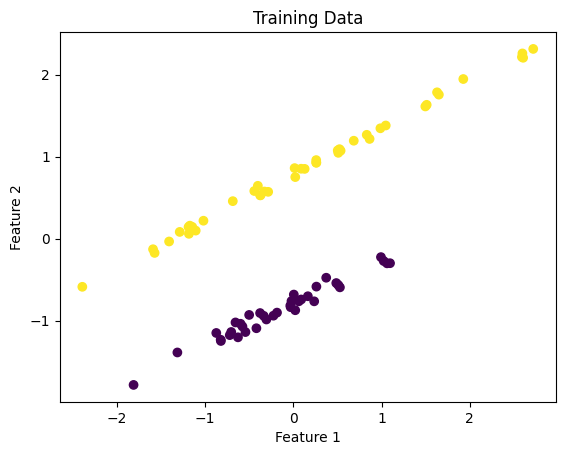

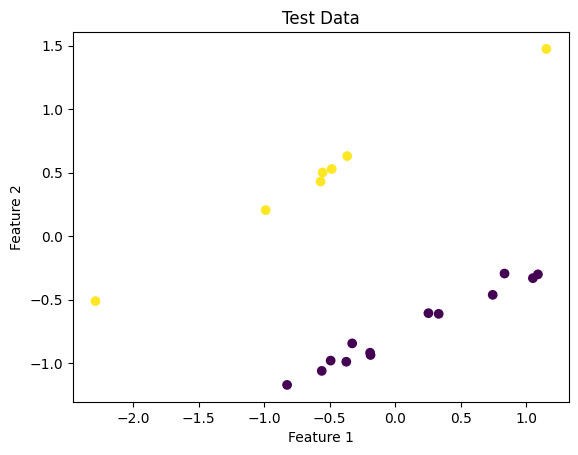

In [15]:
# Visualization

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.title("Training Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("Test Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()